# Experiment 6: Dimensionality Reduction and Model Evaluation (With and Without PCA)

**Dataset:** Spambase (UCI) — 4601 samples, 57 features, binary target `class` (1 = spam, 0 = not spam)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
                              ConfusionMatrixDisplay, roc_curve, auc, classification_report)

from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, AdaBoostClassifier,
                               GradientBoostingClassifier, StackingClassifier)
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
RANDOM_STATE = 42

## 1. Load Dataset

In [2]:
df = pd.read_csv(r"C:\Users\SSN\Downloads\archive(11)\spambase_csv.csv")
print("Shape:", df.shape)
df.head()

Shape: (4601, 58)


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


class
0    2788
1    1813
Name: count, dtype: int64


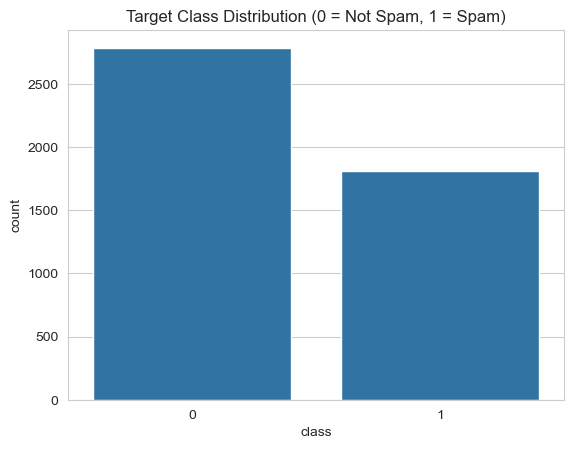

In [3]:
print(df['class'].value_counts())
sns.countplot(x='class', data=df)
plt.title("Target Class Distribution (0 = Not Spam, 1 = Spam)")
plt.show()

In [4]:
X = df.drop(columns=['class'])
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit ONLY on train
X_test_scaled = scaler.transform(X_test)          # reuse same scaler on test

print("Train:", X_train_scaled.shape, " Test:", X_test_scaled.shape)

Train: (3680, 57)  Test: (921, 57)


## 2. PCA — Scree Plot & Component Selection

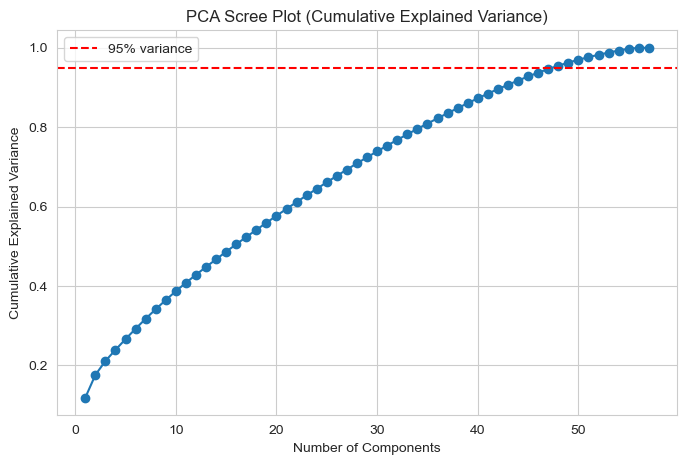

Components chosen for 95% variance: 48
Explained variance with 48 components: 95.49%


In [5]:
pca_full = PCA().fit(X_train_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(cum_var)+1), cum_var, marker='o')
plt.axhline(0.95, color='r', linestyle='--', label='95% variance')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Scree Plot (Cumulative Explained Variance)")
plt.legend()
plt.show()

n_components = np.argmax(cum_var >= 0.95) + 1
print(f"Components chosen for 95% variance: {n_components}")
print(f"Explained variance with {n_components} components: {cum_var[n_components-1]*100:.2f}%")

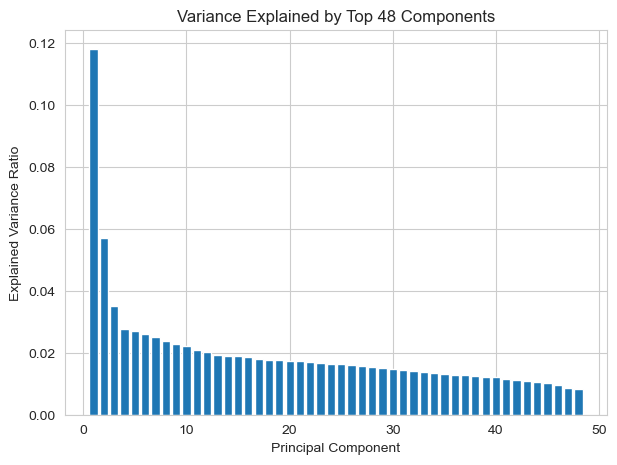

In [6]:
pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_scaled)   # fit ONLY on train
X_test_pca = pca.transform(X_test_scaled)          # reuse same PCA on test

plt.figure(figsize=(7,5))
plt.bar(range(1, n_components+1), pca.explained_variance_ratio_)
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title(f"Variance Explained by Top {n_components} Components")
plt.show()

## 3. Helper Function — Tune, Cross-Validate, Evaluate, Visualize

In [7]:
results = []  # collects summary rows for final comparison

def run_experiment(name, model, param_grid, X_tr, X_te, y_tr, y_te, setting):
    """Grid-search + 5-fold CV tuning, test evaluation, confusion matrix & ROC plot."""
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    grid = GridSearchCV(model, param_grid, cv=cv, scoring='f1', n_jobs=-1)
    grid.fit(X_tr, y_tr)
    best_model = grid.best_estimator_

    fold_scores = cross_val_score(best_model, X_tr, y_tr, cv=cv, scoring='accuracy')

    y_pred = best_model.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred)

    print(f"--- {name} [{setting}] ---")
    print("Best Params:", grid.best_params_)
    print("5-Fold CV Accuracy per fold:", np.round(fold_scores, 4))
    print(f"CV Avg Accuracy: {fold_scores.mean():.4f} | Test Accuracy: {acc:.4f} | Test F1: {f1:.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    cm = confusion_matrix(y_te, y_pred)
    ConfusionMatrixDisplay(cm).plot(ax=axes[0], colorbar=False, cmap='Blues')
    axes[0].set_title(f"{name} ({setting}) - Confusion Matrix")

    if hasattr(best_model, "predict_proba"):
        y_score = best_model.predict_proba(X_te)[:, 1]
    else:
        y_score = best_model.decision_function(X_te)
    fpr, tpr, _ = roc_curve(y_te, y_score)
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].set_title(f"{name} ({setting}) - ROC Curve")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    results.append({
        "Model": name, "Setting": setting, "Best Params": grid.best_params_,
        "CV Avg Accuracy": fold_scores.mean(), "Test Accuracy": acc,
        "Test F1": f1, "ROC AUC": roc_auc
    })
    return best_model

## 4. Models — No-PCA vs With-PCA (Hyperparameter Tuned, 5-Fold CV, Visualized)

### SVM

--- SVM [No-PCA] ---
Best Params: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
5-Fold CV Accuracy per fold: [0.9457 0.9402 0.9429 0.9361 0.9171]
CV Avg Accuracy: 0.9364 | Test Accuracy: 0.9283 | Test F1: 0.9065


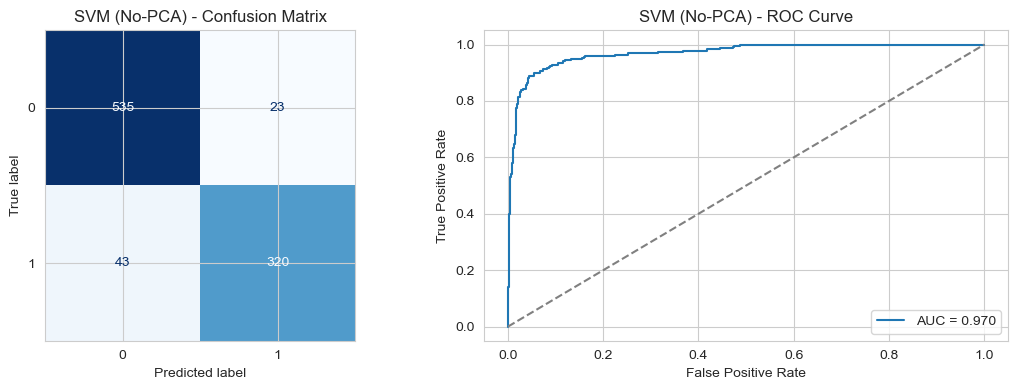

In [8]:
model = SVC(probability=True, random_state=RANDOM_STATE)
param_grid = {'C': [0.1, 1, 10], 'kernel': ['rbf', 'linear'], 'gamma': ['scale', 0.01]}

# --- Without PCA ---
_ = run_experiment("SVM", model, param_grid, X_train_scaled, X_test_scaled, y_train, y_test, "No-PCA")

--- SVM [With-PCA] ---
Best Params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
5-Fold CV Accuracy per fold: [0.9429 0.9389 0.9348 0.9334 0.9158]
CV Avg Accuracy: 0.9332 | Test Accuracy: 0.9273 | Test F1: 0.9058


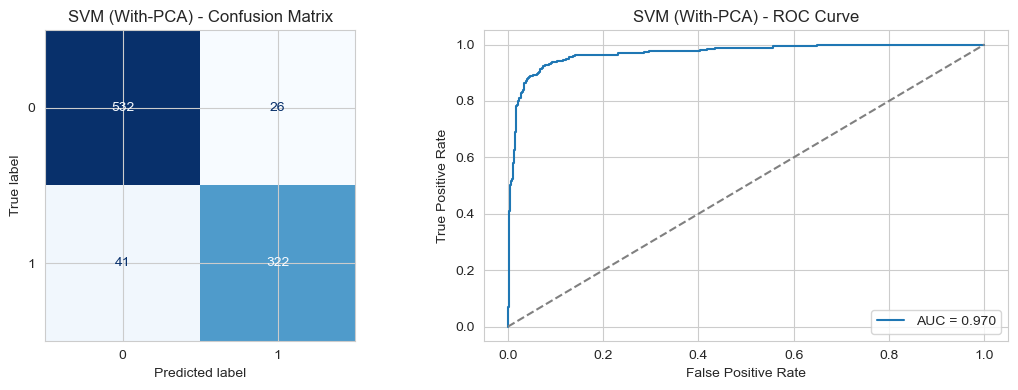

In [9]:
model = SVC(probability=True, random_state=RANDOM_STATE)
param_grid = {'C': [0.1, 1, 10], 'kernel': ['rbf', 'linear'], 'gamma': ['scale', 0.01]}

# --- With PCA ---
_ = run_experiment("SVM", model, param_grid, X_train_pca, X_test_pca, y_train, y_test, "With-PCA")

### Naive Bayes

--- Naive Bayes [No-PCA] ---
Best Params: {'var_smoothing': 1e-08}
5-Fold CV Accuracy per fold: [0.8207 0.8166 0.8342 0.8043 0.7989]
CV Avg Accuracy: 0.8149 | Test Accuracy: 0.8328 | Test F1: 0.8188


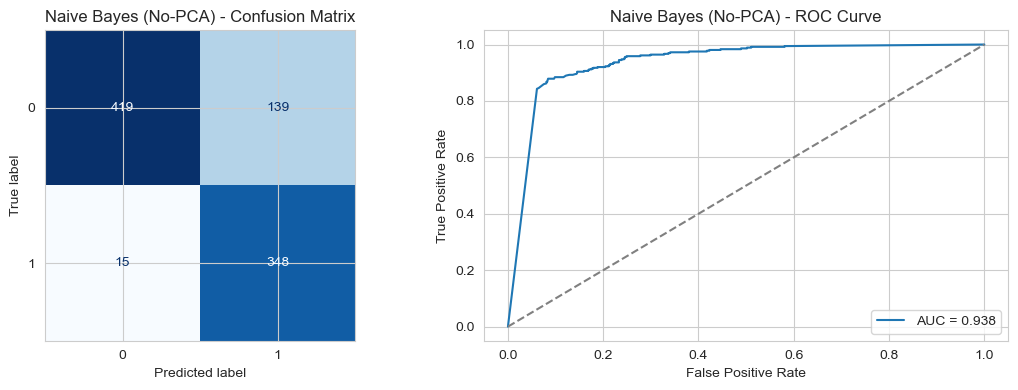

In [10]:
model = GaussianNB()
param_grid = {'var_smoothing': [1e-9, 1e-8, 1e-7]}

# --- Without PCA ---
_ = run_experiment("Naive Bayes", model, param_grid, X_train_scaled, X_test_scaled, y_train, y_test, "No-PCA")

--- Naive Bayes [With-PCA] ---
Best Params: {'var_smoothing': 1e-09}
5-Fold CV Accuracy per fold: [0.8492 0.7677 0.8451 0.8207 0.7405]
CV Avg Accuracy: 0.8046 | Test Accuracy: 0.8339 | Test F1: 0.8123


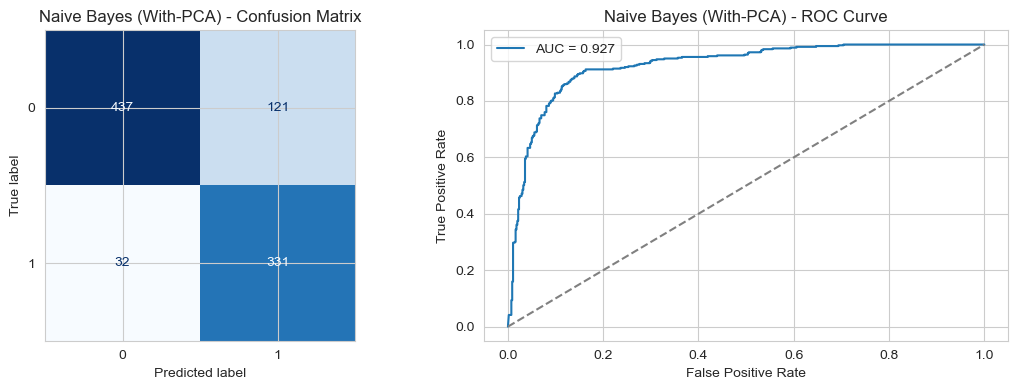

In [11]:
model = GaussianNB()
param_grid = {'var_smoothing': [1e-9, 1e-8, 1e-7]}

# --- With PCA ---
_ = run_experiment("Naive Bayes", model, param_grid, X_train_pca, X_test_pca, y_train, y_test, "With-PCA")

### KNN

--- KNN [No-PCA] ---
Best Params: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}
5-Fold CV Accuracy per fold: [0.9389 0.928  0.9253 0.9266 0.9076]
CV Avg Accuracy: 0.9253 | Test Accuracy: 0.9207 | Test F1: 0.8944


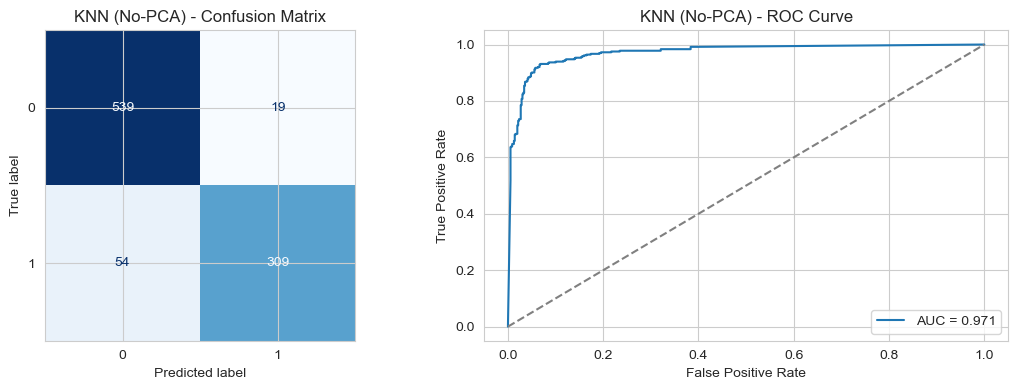

In [12]:
model = KNeighborsClassifier()
param_grid = {'n_neighbors': [3, 5, 7, 9], 'weights': ['uniform', 'distance'], 'metric': ['euclidean', 'manhattan']}

# --- Without PCA ---
_ = run_experiment("KNN", model, param_grid, X_train_scaled, X_test_scaled, y_train, y_test, "No-PCA")

--- KNN [With-PCA] ---
Best Params: {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'distance'}
5-Fold CV Accuracy per fold: [0.9212 0.9239 0.9293 0.9226 0.9062]
CV Avg Accuracy: 0.9207 | Test Accuracy: 0.9164 | Test F1: 0.8935


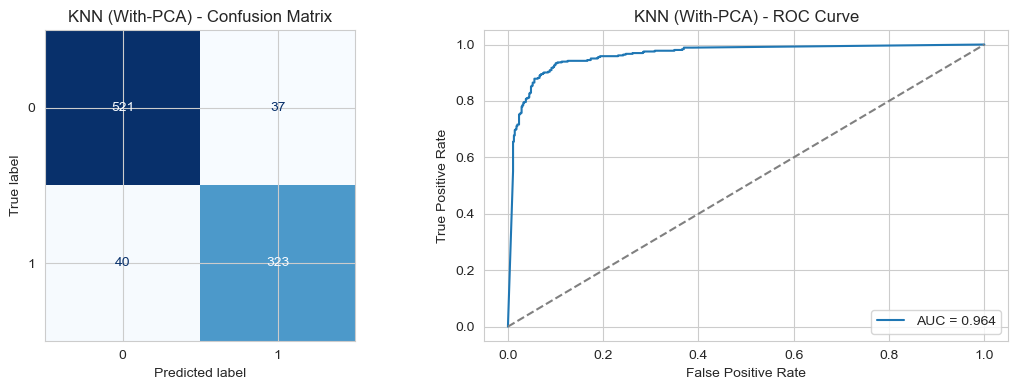

In [13]:
model = KNeighborsClassifier()
param_grid = {'n_neighbors': [3, 5, 7, 9], 'weights': ['uniform', 'distance'], 'metric': ['euclidean', 'manhattan']}

# --- With PCA ---
_ = run_experiment("KNN", model, param_grid, X_train_pca, X_test_pca, y_train, y_test, "With-PCA")

### Logistic Regression

--- Logistic Regression [No-PCA] ---
Best Params: {'C': 10, 'penalty': 'l2'}
5-Fold CV Accuracy per fold: [0.9429 0.9226 0.9348 0.9076 0.9144]
CV Avg Accuracy: 0.9245 | Test Accuracy: 0.9262 | Test F1: 0.9048


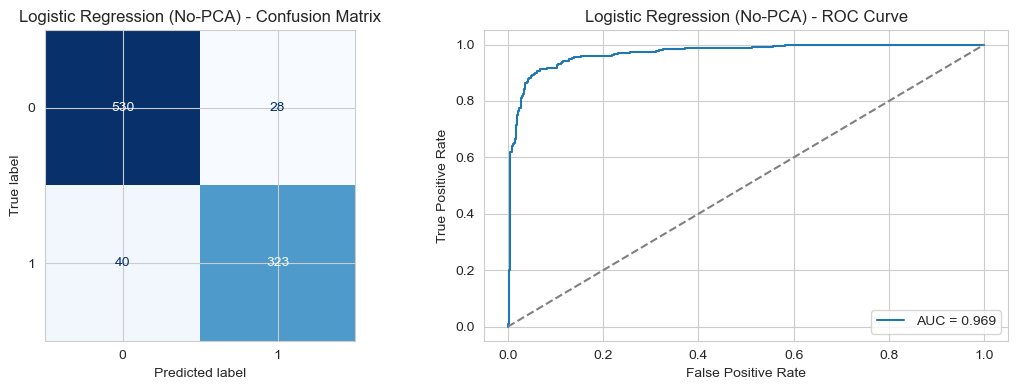

In [14]:
model = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
param_grid = {'C': [0.01, 0.1, 1, 10], 'penalty': ['l2']}

# --- Without PCA ---
_ = run_experiment("Logistic Regression", model, param_grid, X_train_scaled, X_test_scaled, y_train, y_test, "No-PCA")

--- Logistic Regression [With-PCA] ---
Best Params: {'C': 10, 'penalty': 'l2'}
5-Fold CV Accuracy per fold: [0.9348 0.9239 0.928  0.913  0.9158]
CV Avg Accuracy: 0.9231 | Test Accuracy: 0.9294 | Test F1: 0.9096


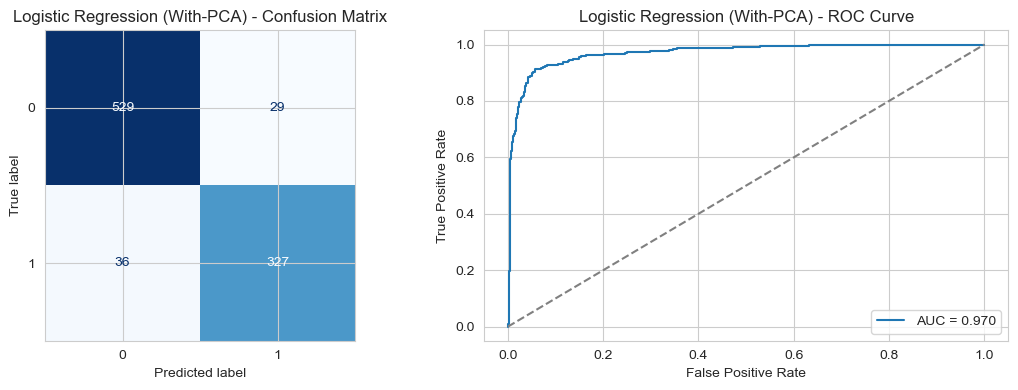

In [15]:
model = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
param_grid = {'C': [0.01, 0.1, 1, 10], 'penalty': ['l2']}

# --- With PCA ---
_ = run_experiment("Logistic Regression", model, param_grid, X_train_pca, X_test_pca, y_train, y_test, "With-PCA")

### Decision Tree

--- Decision Tree [No-PCA] ---
Best Params: {'max_depth': None, 'min_samples_split': 5}
5-Fold CV Accuracy per fold: [0.928  0.9321 0.9171 0.9239 0.9103]
CV Avg Accuracy: 0.9223 | Test Accuracy: 0.9131 | Test F1: 0.8889


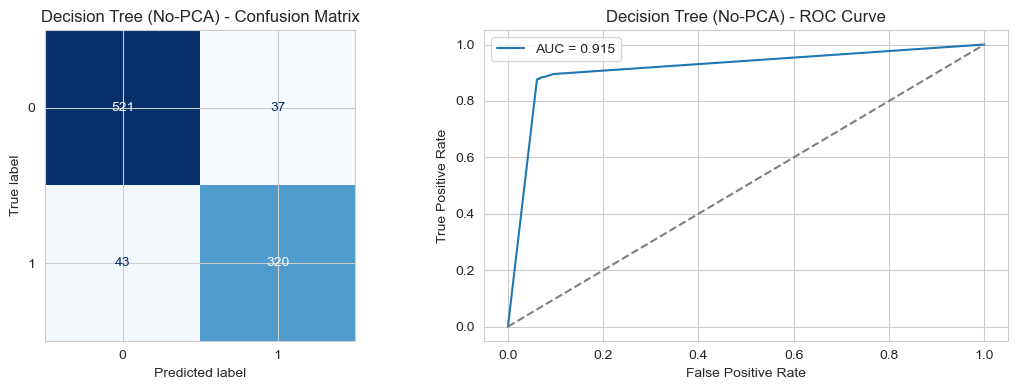

In [16]:
model = DecisionTreeClassifier(random_state=RANDOM_STATE)
param_grid = {'max_depth': [3, 5, 10, None], 'min_samples_split': [2, 5, 10]}

# --- Without PCA ---
_ = run_experiment("Decision Tree", model, param_grid, X_train_scaled, X_test_scaled, y_train, y_test, "No-PCA")

--- Decision Tree [With-PCA] ---
Best Params: {'max_depth': 10, 'min_samples_split': 2}
5-Fold CV Accuracy per fold: [0.8804 0.8899 0.8913 0.9022 0.8709]
CV Avg Accuracy: 0.8870 | Test Accuracy: 0.8740 | Test F1: 0.8470


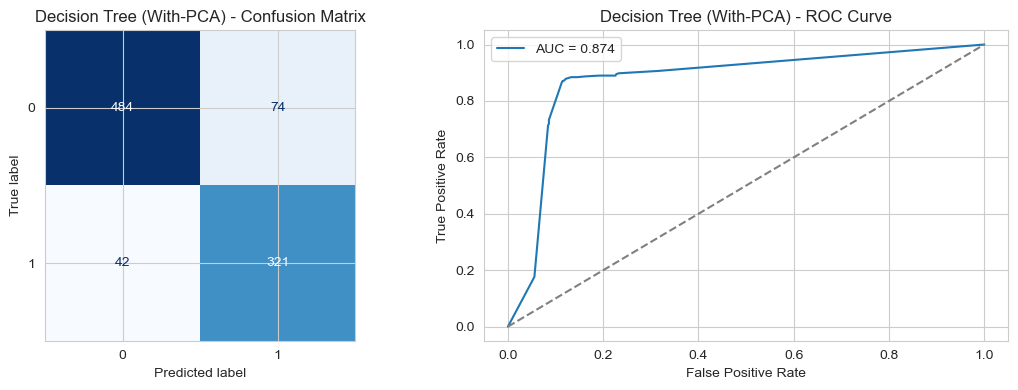

In [17]:
model = DecisionTreeClassifier(random_state=RANDOM_STATE)
param_grid = {'max_depth': [3, 5, 10, None], 'min_samples_split': [2, 5, 10]}

# --- With PCA ---
_ = run_experiment("Decision Tree", model, param_grid, X_train_pca, X_test_pca, y_train, y_test, "With-PCA")

### Random Forest

--- Random Forest [No-PCA] ---
Best Params: {'max_depth': None, 'n_estimators': 100}
5-Fold CV Accuracy per fold: [0.9592 0.9552 0.9538 0.947  0.9457]
CV Avg Accuracy: 0.9522 | Test Accuracy: 0.9446 | Test F1: 0.9283


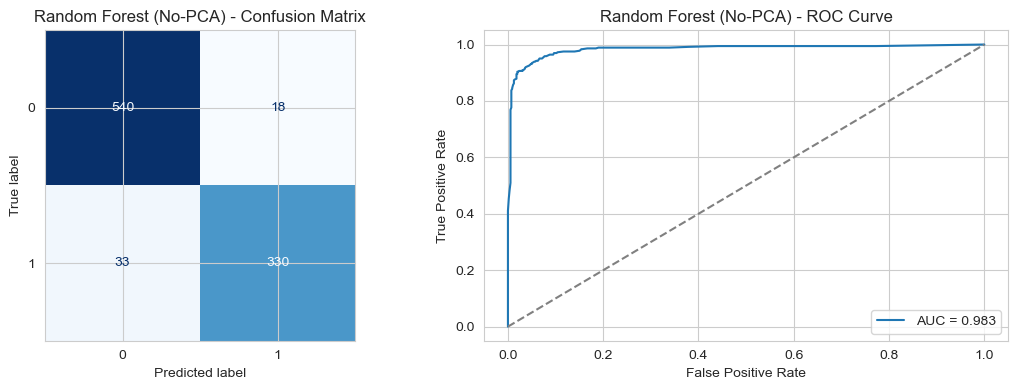

In [18]:
model = RandomForestClassifier(random_state=RANDOM_STATE)
param_grid = {'n_estimators': [100, 200], 'max_depth': [5, 10, None]}

# --- Without PCA ---
_ = run_experiment("Random Forest", model, param_grid, X_train_scaled, X_test_scaled, y_train, y_test, "No-PCA")

--- Random Forest [With-PCA] ---
Best Params: {'max_depth': None, 'n_estimators': 200}
5-Fold CV Accuracy per fold: [0.9293 0.9402 0.9457 0.9429 0.9076]
CV Avg Accuracy: 0.9332 | Test Accuracy: 0.9229 | Test F1: 0.9010


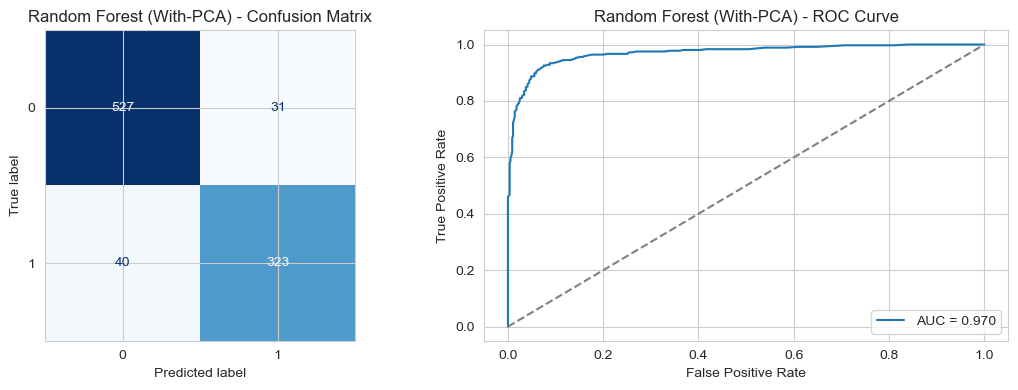

In [19]:
model = RandomForestClassifier(random_state=RANDOM_STATE)
param_grid = {'n_estimators': [100, 200], 'max_depth': [5, 10, None]}

# --- With PCA ---
_ = run_experiment("Random Forest", model, param_grid, X_train_pca, X_test_pca, y_train, y_test, "With-PCA")

### AdaBoost

--- AdaBoost [No-PCA] ---
Best Params: {'learning_rate': 0.5, 'n_estimators': 100}
5-Fold CV Accuracy per fold: [0.9457 0.9375 0.9565 0.9497 0.9389]
CV Avg Accuracy: 0.9457 | Test Accuracy: 0.9370 | Test F1: 0.9192


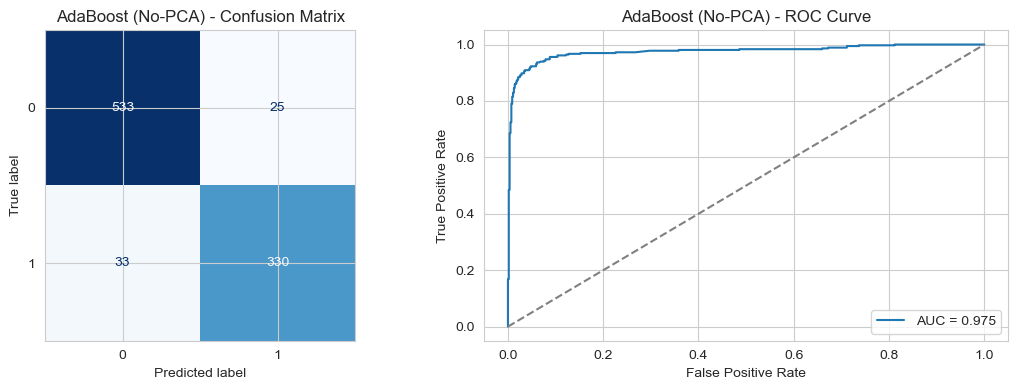

In [20]:
model = AdaBoostClassifier(random_state=RANDOM_STATE)
param_grid = {'n_estimators': [50, 100], 'learning_rate': [0.5, 1.0]}

# --- Without PCA ---
_ = run_experiment("AdaBoost", model, param_grid, X_train_scaled, X_test_scaled, y_train, y_test, "No-PCA")

--- AdaBoost [With-PCA] ---
Best Params: {'learning_rate': 1.0, 'n_estimators': 100}
5-Fold CV Accuracy per fold: [0.9239 0.9293 0.9239 0.913  0.909 ]
CV Avg Accuracy: 0.9198 | Test Accuracy: 0.9110 | Test F1: 0.8835


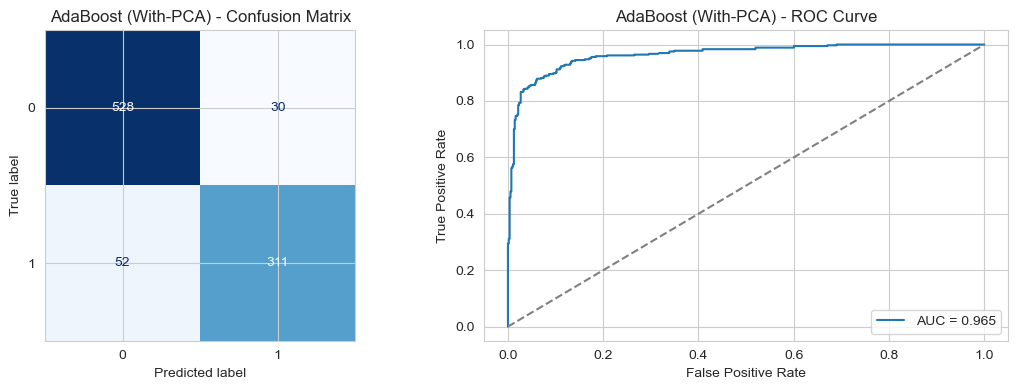

In [21]:
model = AdaBoostClassifier(random_state=RANDOM_STATE)
param_grid = {'n_estimators': [50, 100], 'learning_rate': [0.5, 1.0]}

# --- With PCA ---
_ = run_experiment("AdaBoost", model, param_grid, X_train_pca, X_test_pca, y_train, y_test, "With-PCA")

### Gradient Boosting

--- Gradient Boosting [No-PCA] ---
Best Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 150}
5-Fold CV Accuracy per fold: [0.9497 0.9497 0.9633 0.9484 0.9484]
CV Avg Accuracy: 0.9519 | Test Accuracy: 0.9457 | Test F1: 0.9309


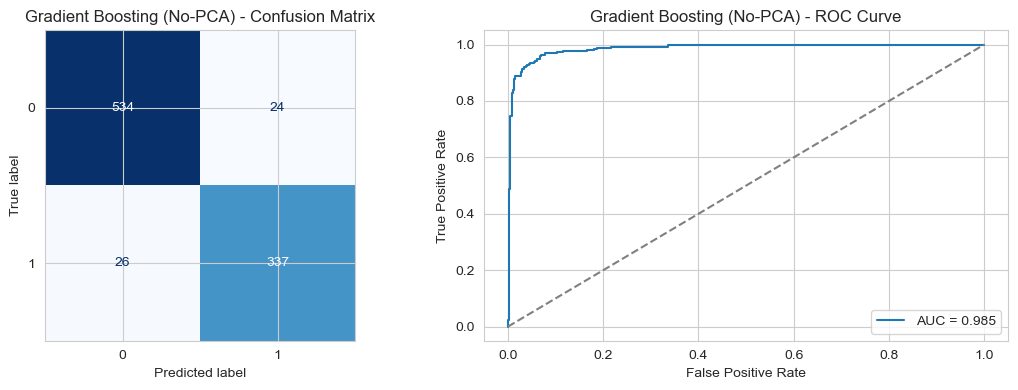

In [22]:
model = GradientBoostingClassifier(random_state=RANDOM_STATE)
param_grid = {'n_estimators': [100, 150], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 5]}

# --- Without PCA ---
_ = run_experiment("Gradient Boosting", model, param_grid, X_train_scaled, X_test_scaled, y_train, y_test, "No-PCA")

--- Gradient Boosting [With-PCA] ---
Best Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 150}
5-Fold CV Accuracy per fold: [0.9416 0.9334 0.9457 0.9416 0.9171]
CV Avg Accuracy: 0.9359 | Test Accuracy: 0.9251 | Test F1: 0.9048


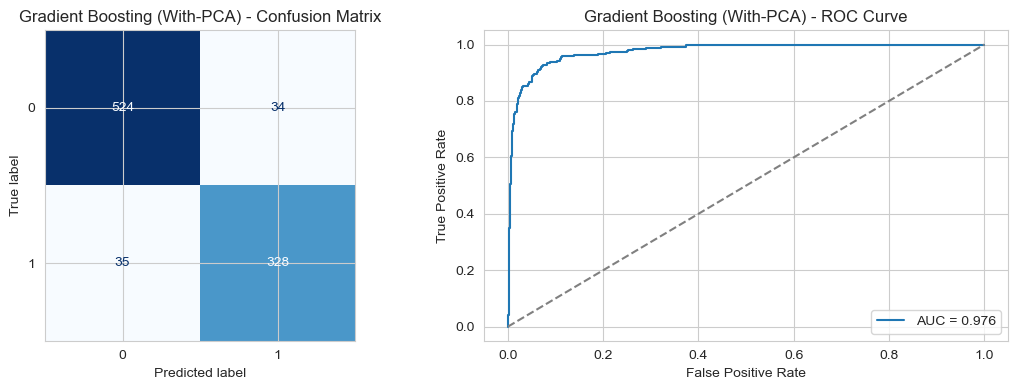

In [23]:
model = GradientBoostingClassifier(random_state=RANDOM_STATE)
param_grid = {'n_estimators': [100, 150], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 5]}

# --- With PCA ---
_ = run_experiment("Gradient Boosting", model, param_grid, X_train_pca, X_test_pca, y_train, y_test, "With-PCA")

### XGBoost

--- XGBoost [No-PCA] ---
Best Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 150}
5-Fold CV Accuracy per fold: [0.9565 0.9511 0.9592 0.9552 0.9443]
CV Avg Accuracy: 0.9533 | Test Accuracy: 0.9479 | Test F1: 0.9335


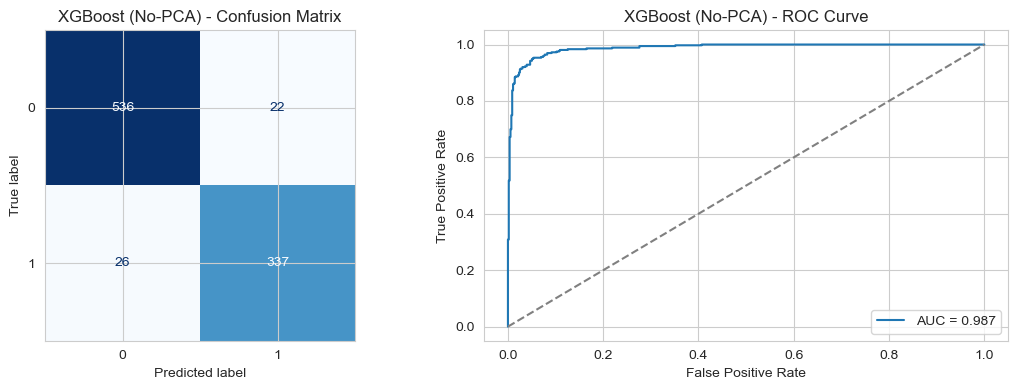

In [24]:
model = XGBClassifier(eval_metric='logloss', random_state=RANDOM_STATE)
param_grid = {'n_estimators': [100, 150], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 5]}

# --- Without PCA ---
_ = run_experiment("XGBoost", model, param_grid, X_train_scaled, X_test_scaled, y_train, y_test, "No-PCA")

--- XGBoost [With-PCA] ---
Best Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 150}
5-Fold CV Accuracy per fold: [0.9429 0.9429 0.9497 0.9416 0.9185]
CV Avg Accuracy: 0.9391 | Test Accuracy: 0.9338 | Test F1: 0.9159


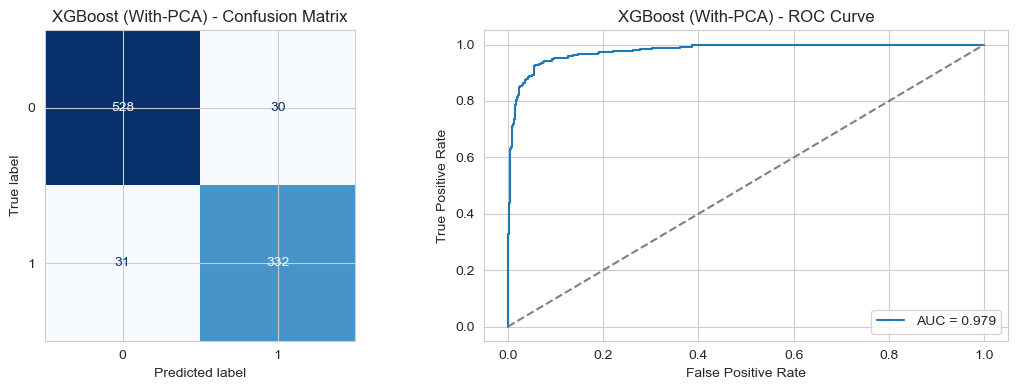

In [25]:
model = XGBClassifier(eval_metric='logloss', random_state=RANDOM_STATE)
param_grid = {'n_estimators': [100, 150], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 5]}

# --- With PCA ---
_ = run_experiment("XGBoost", model, param_grid, X_train_pca, X_test_pca, y_train, y_test, "With-PCA")

### Stacking (Base Learners + Meta-Learner)

--- Stacking [No-PCA] ---
Best Params: {'final_estimator__C': 10}
5-Fold CV Accuracy per fold: [0.966  0.9592 0.9565 0.9538 0.9484]
CV Avg Accuracy: 0.9568 | Test Accuracy: 0.9501 | Test F1: 0.9363


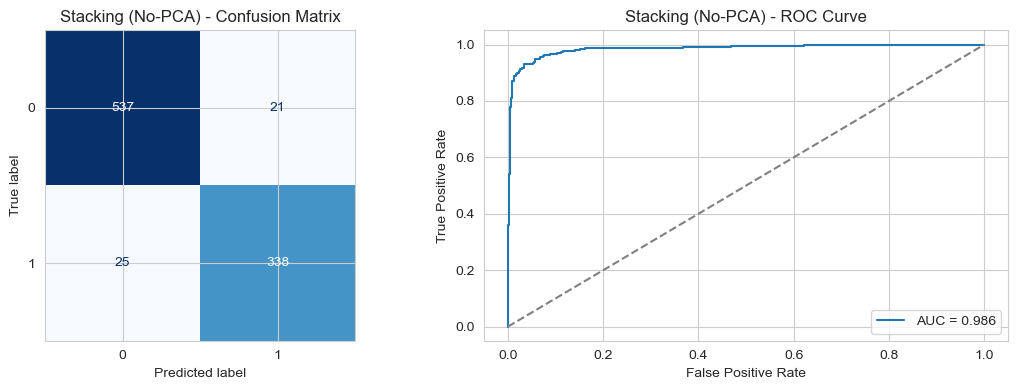

In [26]:
base_learners = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)),
    ('svm', SVC(probability=True, kernel='rbf', random_state=RANDOM_STATE)),
    ('knn', KNeighborsClassifier(n_neighbors=5))
]
meta_learner = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)

stack_model = StackingClassifier(estimators=base_learners, final_estimator=meta_learner, cv=5)
stack_grid = {'final_estimator__C': [0.1, 1, 10]}

# --- Without PCA ---
_ = run_experiment("Stacking", stack_model, stack_grid, X_train_scaled, X_test_scaled, y_train, y_test, "No-PCA")

--- Stacking [With-PCA] ---
Best Params: {'final_estimator__C': 10}
5-Fold CV Accuracy per fold: [0.9402 0.9402 0.9429 0.9497 0.9171]
CV Avg Accuracy: 0.9380 | Test Accuracy: 0.9251 | Test F1: 0.9043


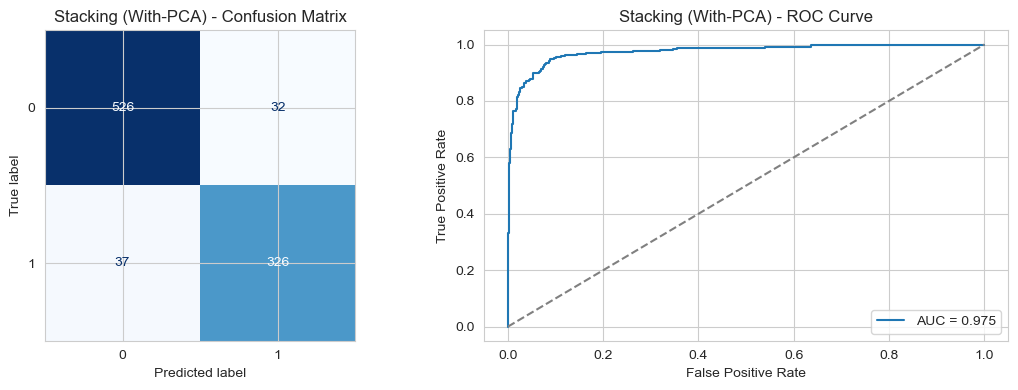

In [27]:
stack_model = StackingClassifier(estimators=base_learners, final_estimator=meta_learner, cv=5)

# --- With PCA ---
_ = run_experiment("Stacking", stack_model, stack_grid, X_train_pca, X_test_pca, y_train, y_test, "With-PCA")

## 5. Summary — No-PCA vs With-PCA Comparison

In [29]:
results_df = pd.DataFrame(results)
summary = results_df.pivot(index='Model', columns='Setting',
                            values=['CV Avg Accuracy', 'Test Accuracy', 'Test F1', 'ROC AUC'])
summary

CV Avg Accuracy           Test Accuracy            \
Setting                      No-PCA  With-PCA        No-PCA  With-PCA   
Model                                                                   
AdaBoost                   0.945652  0.919837      0.937025  0.910966   
Decision Tree              0.922283  0.886957      0.913138  0.874050   
Gradient Boosting          0.951902  0.935870      0.945711  0.925081   
KNN                        0.925272  0.920652      0.920738  0.916395   
Logistic Regression        0.924457  0.923098      0.926167  0.929425   
Naive Bayes                0.814946  0.804620      0.832790  0.833876   
Random Forest              0.952174  0.933152      0.944625  0.922910   
SVM                        0.936413  0.933152      0.928339  0.927253   
Stacking                   0.956793  0.938043      0.950054  0.925081   
XGBoost                    0.953261  0.939130      0.947883  0.933768   

                      Test F1             ROC AUC            
Setting                No-PCA  With-PCA    No-PCA  With-PCA  
Model                                                        
AdaBoost             0.919220  0.883523  0.974977  0.964619  
Decision Tree        0.888889  0.846966  0.914509  0.873772  
Gradient Boosting    0.930939  0.904828  0.985461  0.975518  
KNN                  0.894356  0.893499  0.971232  0.963639  
Logistic Regression  0.904762  0.909597  0.968833  0.970359  
Naive Bayes          0.818824  0.812270  0.937718  0.926570  
Random Forest        0.928270  0.900976  0.983432  0.970284  
SVM                  0.906516  0.905767  0.969880  0.969825  
Stacking             0.936288  0.904300  0.985589  0.974634  
XGBoost              0.933518  0.915862  0.987379  0.978820

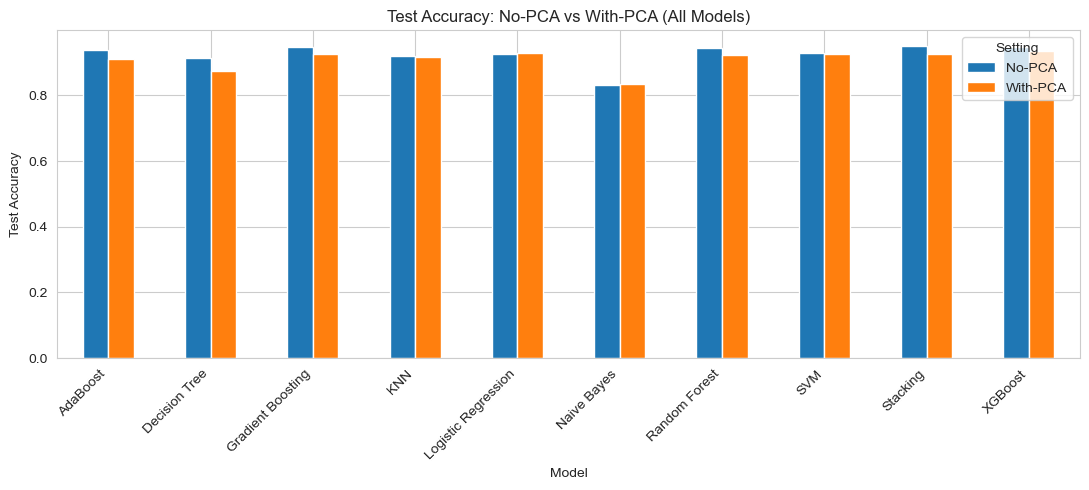

In [30]:
pivot_acc = results_df.pivot(index='Model', columns='Setting', values='Test Accuracy')
pivot_acc = pivot_acc[['No-PCA', 'With-PCA']]

pivot_acc.plot(kind='bar', figsize=(11, 5))
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy: No-PCA vs With-PCA (All Models)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

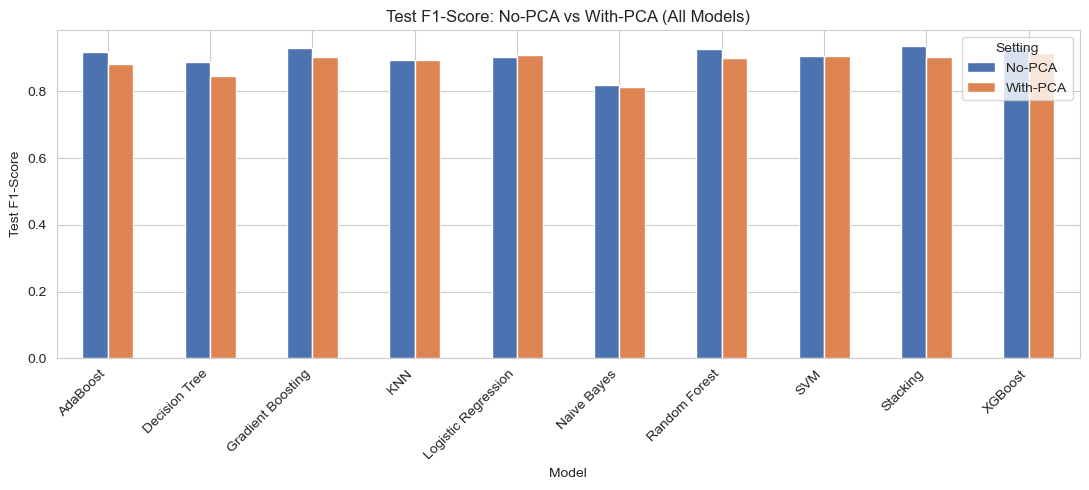

In [31]:
pivot_f1 = results_df.pivot(index='Model', columns='Setting', values='Test F1')
pivot_f1 = pivot_f1[['No-PCA', 'With-PCA']]

pivot_f1.plot(kind='bar', figsize=(11, 5), color=['#4C72B0', '#DD8452'])
plt.ylabel("Test F1-Score")
plt.title("Test F1-Score: No-PCA vs With-PCA (All Models)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [32]:
cv_pivot = results_df.pivot(index='Model', columns='Setting', values='CV Avg Accuracy')
cv_pivot = cv_pivot[['No-PCA', 'With-PCA']]
cv_pivot['Improvement (PCA - NoPCA)'] = cv_pivot['With-PCA'] - cv_pivot['No-PCA']
cv_pivot.sort_values('Improvement (PCA - NoPCA)', ascending=False)

Setting,No-PCA,With-PCA,Improvement (PCA - NoPCA)
Model,,,
Logistic Regression,0.924457,0.923098,-0.001359
SVM,0.936413,0.933152,-0.003261
KNN,0.925272,0.920652,-0.004620
Naive Bayes,0.814946,0.804620,-0.010326
XGBoost,0.953261,0.939130,-0.014130
Gradient Boosting,0.951902,0.935870,-0.016033
Stacking,0.956793,0.938043,-0.018750
Random Forest,0.952174,0.933152,-0.019022
AdaBoost,0.945652,0.919837,-0.025815
